## Data cleaning

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
df = pd.read_csv('.\\salary.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '.data\\salary.csv'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3761 entries, 0 to 3760
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   work_year         3761 non-null   int64 
 1   experience_level  3761 non-null   object
 2   employment_type   3761 non-null   object
 3   job_title         3761 non-null   object
 4   salary            3761 non-null   int64 
 5   salary_currency   3761 non-null   object
 6   salary_in_usd     3761 non-null   int64 
 7   company_location  3761 non-null   object
 8   company_size      3761 non-null   object
dtypes: int64(3), object(6)
memory usage: 264.6+ KB


In [ ]:
df.describe()

,work_year,salary,salary_in_usd
count,3761.000000,3.761000e+03,3761.000000
mean,2022.374103,1.905999e+05,137555.178942
std,0.691252,6.711457e+05,63022.267974
min,2020.000000,6.000000e+03,5132.000000
25%,2022.000000,1.000000e+05,95000.000000
50%,2022.000000,1.375000e+05,135000.000000
75%,2023.000000,1.800000e+05,175000.000000
max,2023.000000,3.040000e+07,450000.000000


In [ ]:
df.shape

(3761, 9)

After a little see, we can see overall the distribution of the dataset. The most important there is not missing values on columns, but in spite of that I'm going to delete the columns: salary and salary_currency therefore for my perspective are innecesary having the column salary_in_usd

In [ ]:
df.drop(['salary','salary_currency'], axis=1, inplace=True)
df.head()

,work_year,experience_level,employment_type,job_title,salary_in_usd,company_location,company_size
0,2023,EN,FT,Applied Scientist,213660,US,L
1,2023,EN,FT,Applied Scientist,130760,US,L
2,2023,EN,FT,Data Quality Analyst,100000,NG,L
3,2023,EN,FT,Compliance Data Analyst,30000,NG,L
4,2023,EN,FT,Applied Scientist,204620,US,L


In [ ]:
df.rename(columns={'salary_in_usd':'salary'}, inplace= True)
df.head()

,work_year,experience_level,employment_type,job_title,salary,company_location,company_size
0,2023,EN,FT,Applied Scientist,213660,US,L
1,2023,EN,FT,Applied Scientist,130760,US,L
2,2023,EN,FT,Data Quality Analyst,100000,NG,L
3,2023,EN,FT,Compliance Data Analyst,30000,NG,L
4,2023,EN,FT,Applied Scientist,204620,US,L


### Review of missing values

We already know that we don't have missing values after review .info(), but I'm going to check again only to be sure

In [ ]:
df.isnull().sum()

work_year           0
experience_level    0
employment_type     0
job_title           0
salary              0
company_location    0
company_size        0
dtype: int64

### Duplicate Value Detection

In [ ]:
df.duplicated().sum()

1355

In [ ]:
print(f'Number of  exactly duplicated: {df.duplicated().sum()}')

Number of  exactly duplicated: 1355


In [ ]:
df.drop_duplicates(inplace=True)
df.shape

(2406, 7)

### Review of data types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2406 entries, 0 to 3760
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   work_year         2406 non-null   int64 
 1   experience_level  2406 non-null   object
 2   employment_type   2406 non-null   object
 3   job_title         2406 non-null   object
 4   salary            2406 non-null   int64 
 5   company_location  2406 non-null   object
 6   company_size      2406 non-null   object
dtypes: int64(2), object(5)
memory usage: 150.4+ KB


We could change the format of the column work_year to date and extract year, but as we are only going to make a simple regretion is not necessary to change the format

### Outlier detection

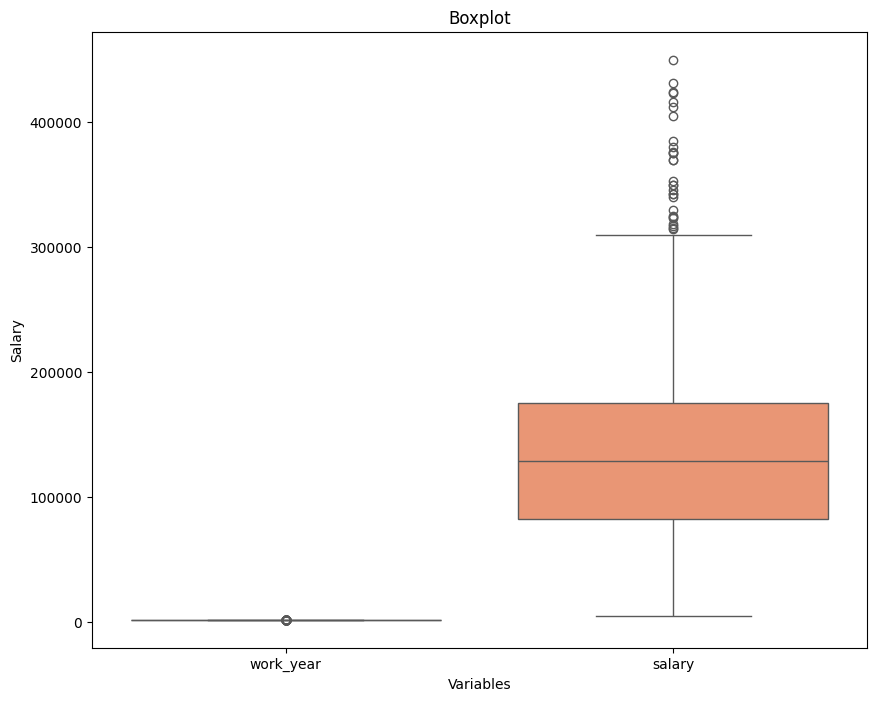

In [ ]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df, palette='Set2')
plt.title('Boxplot')
plt.xlabel('Variables')
plt.ylabel('Salary')
plt.show()

In the column work_year, there are no problems with outliers. However, in the salary column, some outliers can be identified. The methodology I will apply is to remove all observations that fall outside the range defined by 1.5 × IQR.

In [ ]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'company_location', 'company_size'],
      dtype='object')

In [ ]:
num = ["work_year","salary"]
def filter_outliers(df, num_col):
    for col in num_col:
        Q1 = df[col].quantile(0.25)
        Q3 =df[col].quantile(0.75)
        IQR = Q3-Q1
        df = df[(df[col]>=(Q1-1.5*IQR)) & (df[col]<=(Q3+1.5*IQR))]
    return df

In [ ]:
df = filter_outliers(df, num)
df

,work_year,experience_level,employment_type,job_title,salary,company_location,company_size
0,2023,EN,FT,Applied Scientist,213660,US,L
1,2023,EN,FT,Applied Scientist,130760,US,L
2,2023,EN,FT,Data Quality Analyst,100000,NG,L
3,2023,EN,FT,Compliance Data Analyst,30000,NG,L
4,2023,EN,FT,Applied Scientist,204620,US,L
...,...,...,...,...,...,...,...
3680,2021,SE,FT,Principal Data Scientist,173762,DE,M
3681,2021,SE,FT,Principal Data Scientist,235000,US,L
3682,2021,SE,FT,Director of Data Science,168000,JP,S
3683,2021,SE,FT,Data Specialist,165000,US,L


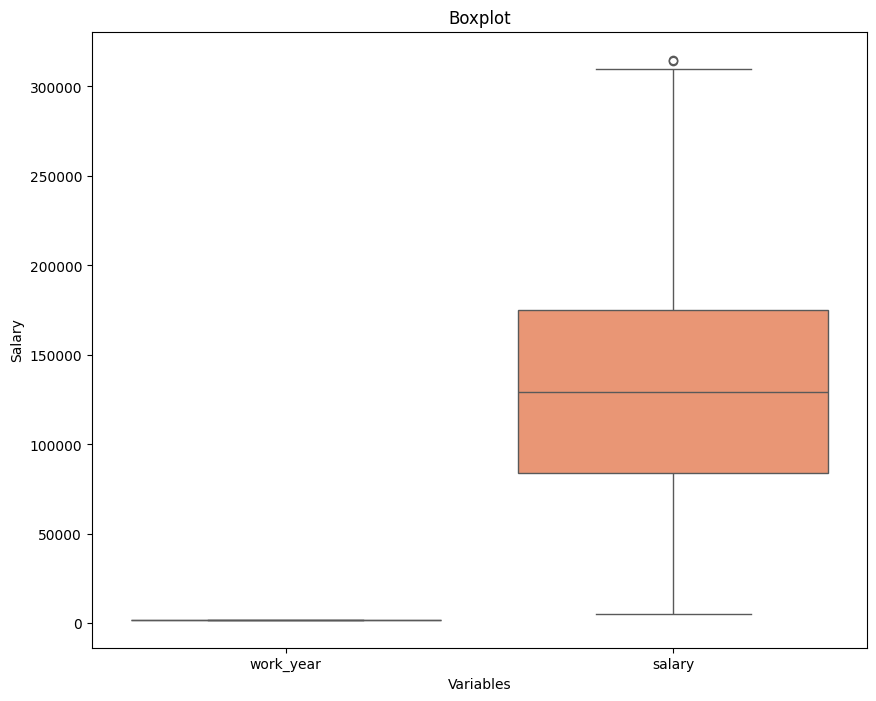

In [ ]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df, palette='Set2')
plt.title('Boxplot')
plt.xlabel('Variables')
plt.ylabel('Salary')
plt.show()

## EDA

### Search for relationship between variables

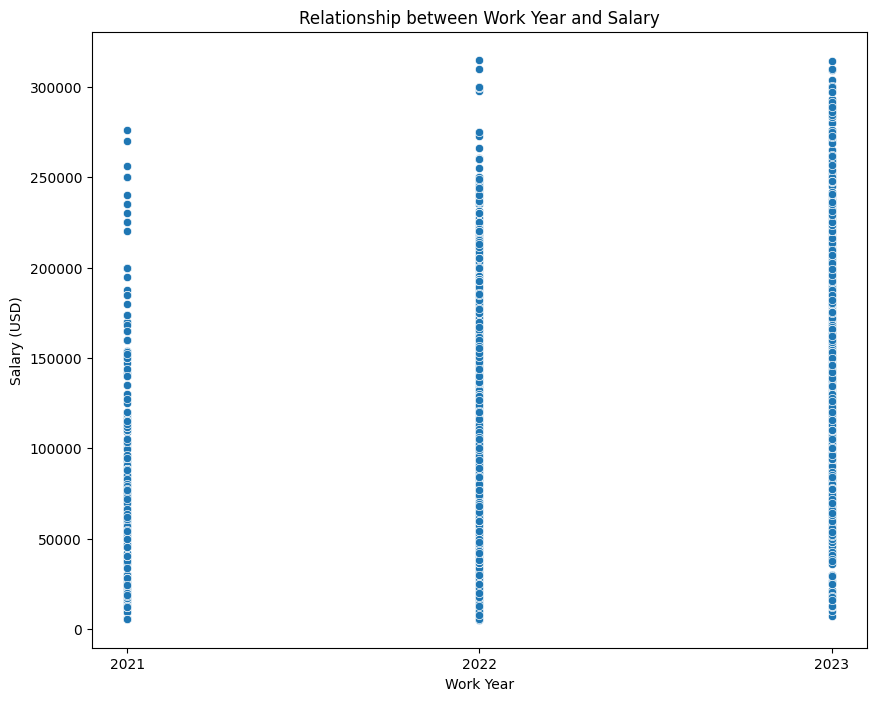

In [ ]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df, x='work_year', y='salary')
plt.title('Relationship between Work Year and Salary')
plt.xlabel('Work Year')
plt.ylabel('Salary (USD)')
plt.xticks(df['work_year'].unique())
plt.show()

### Relation with categorics variables

C:\Users\Carlos\AppData\Local\Temp\ipykernel_7700\2954917164.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


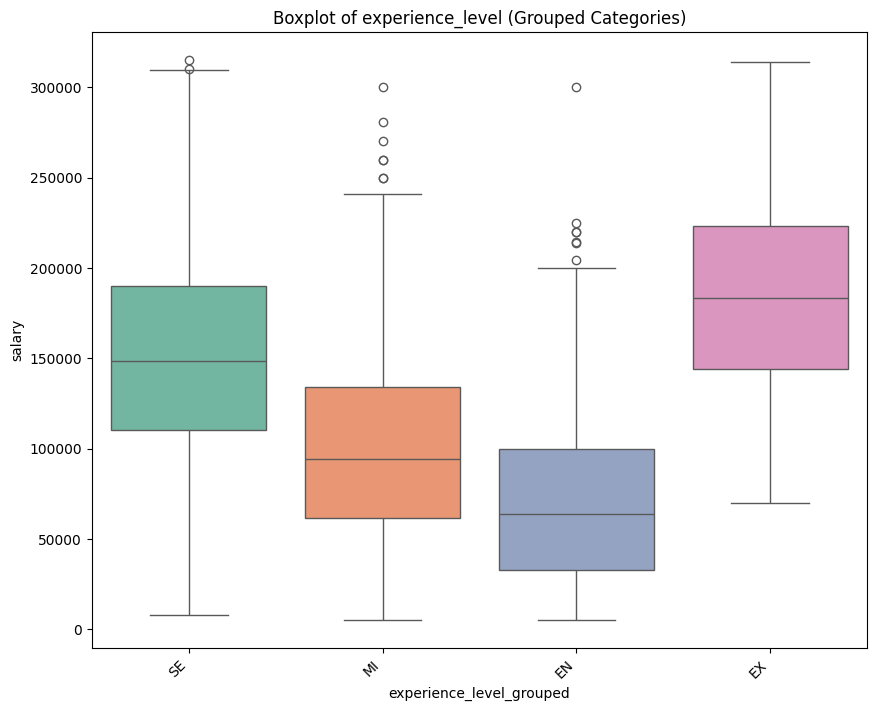

C:\Users\Carlos\AppData\Local\Temp\ipykernel_7700\2954917164.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


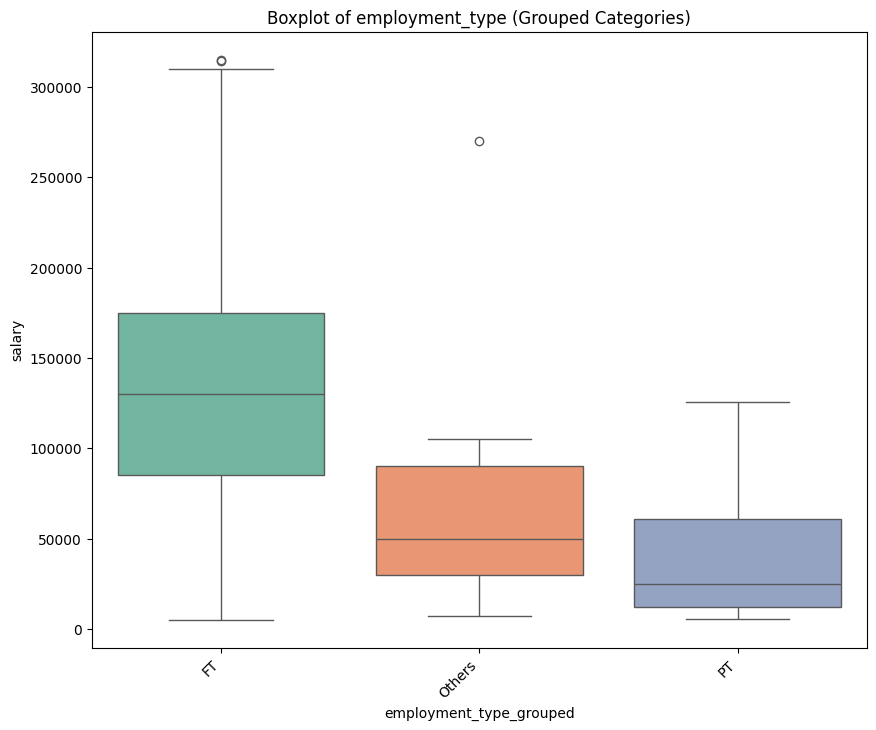

C:\Users\Carlos\AppData\Local\Temp\ipykernel_7700\2954917164.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


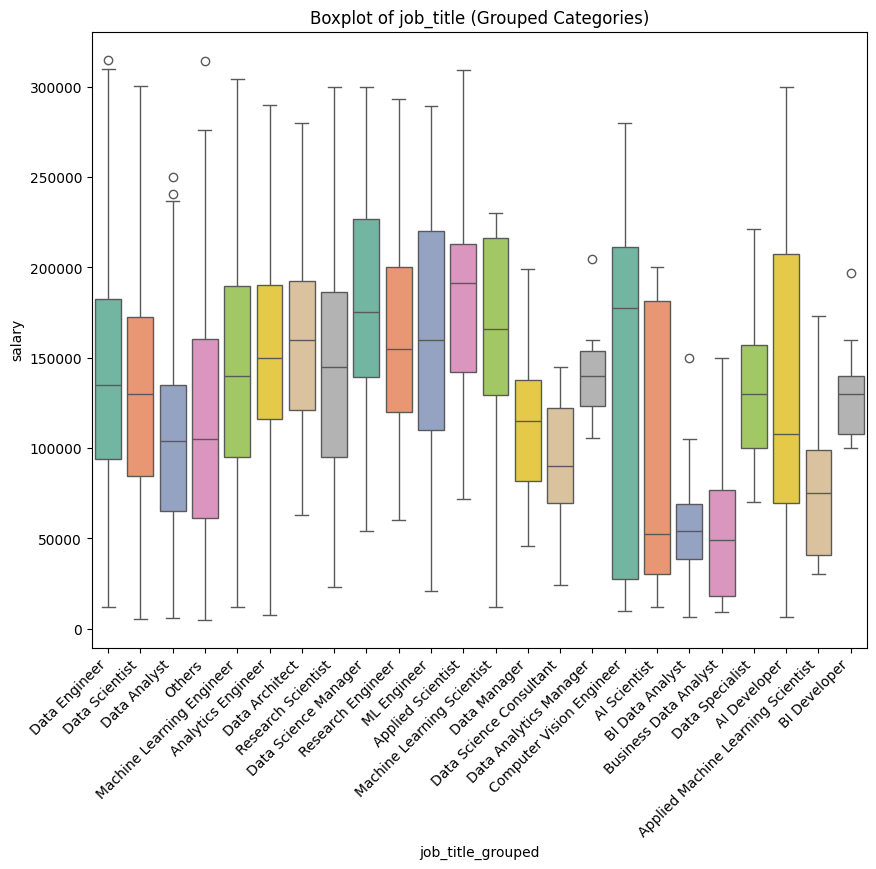

C:\Users\Carlos\AppData\Local\Temp\ipykernel_7700\2954917164.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


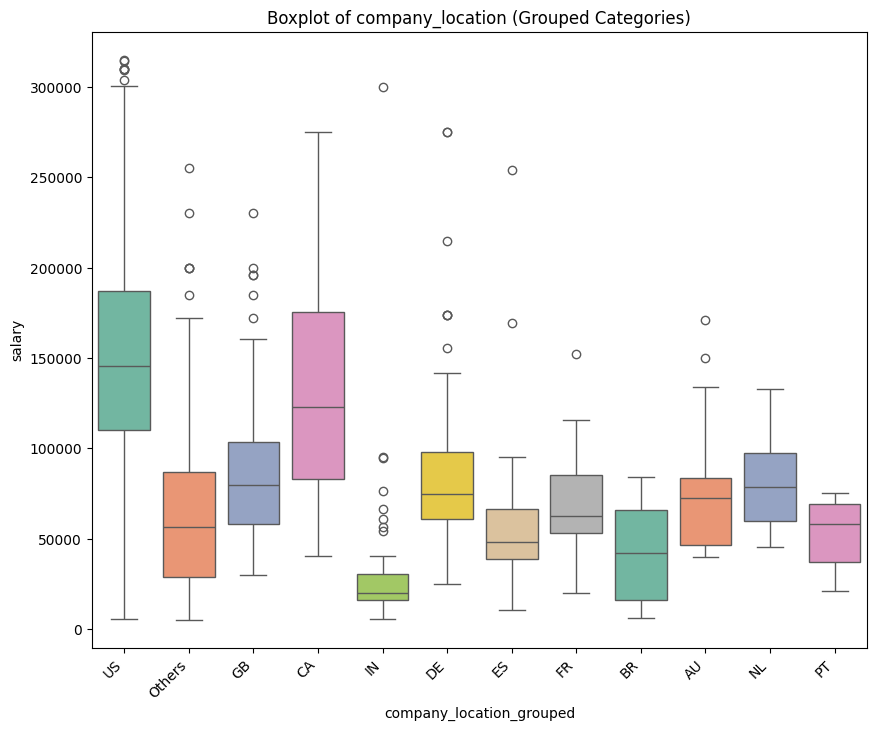

C:\Users\Carlos\AppData\Local\Temp\ipykernel_7700\2954917164.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


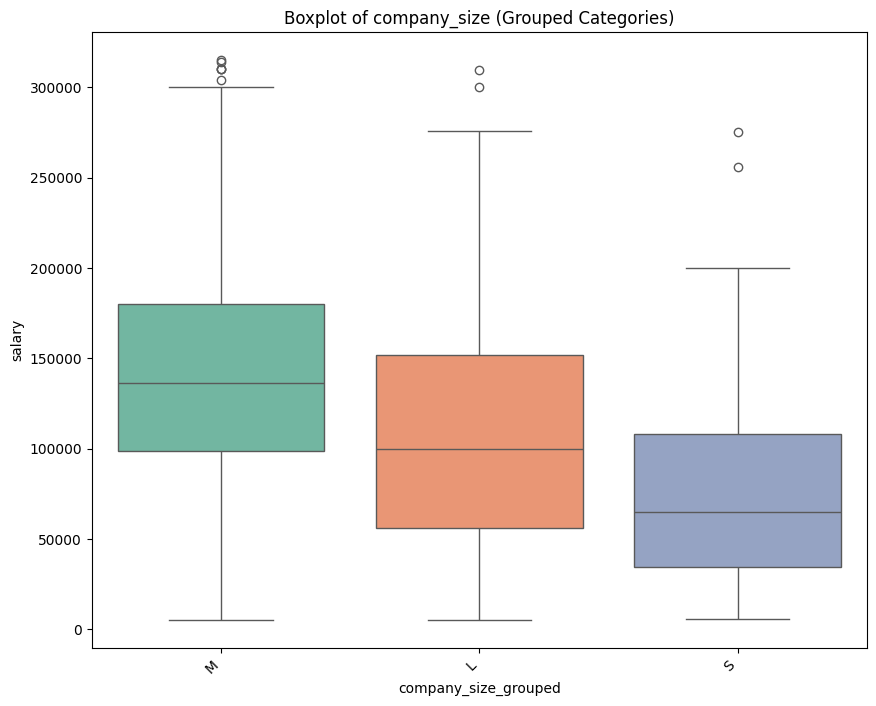

In [ ]:
cat = ['experience_level','employment_type','job_title','company_location','company_size']

for col in cat:
    # Contar valores en la columna actual
    counts = df[col].value_counts()

    # Seleccionar las categorías que tengan más de 15 registros
    top_categories = counts[counts > 10].index

    # Crear una nueva columna agrupada (nota el uso de col, no 'job_title')
    df[f'{col}_grouped'] = df[col].where(df[col].isin(top_categories), 'Others')

    # Crear el boxplot usando la columna agrupada
    plt.figure(figsize=(10, 8))
    sns.boxplot(
        data=df,
        x=f'{col}_grouped',
        y='salary',
        palette='Set2',
        order=df[f'{col}_grouped'].value_counts().index
    )
    plt.title(f'Boxplot of {col} (Grouped Categories)')
    plt.xticks(rotation=45, ha='right')
    plt.show()


After reviewing the visualizations, several insights can be drawn.
There isn’t a clear relationship between year and salary — within each year, salaries vary widely, ranging from entry-level to top-tier values.

Regarding experience level, the results align with expectations: as experience increases, salaries tend to be higher. The median salary by job category is quite representative, while other variables show greater variability.

Across most categories, the interquartile range (IQR) reveals noticeable variation in salary distribution, although this variability is smaller for company location.

As expected, some outliers are present in each category’s salary distribution.

In conclusion, the categories that appear to have the most influence on salary are:
* location
* experience level
* company size
* Job title

The next step is to convert our categorical variables into numerical ones. This way, we’ll have the data in the correct format, allowing us to start building our model.
But before we must to create a new DataFrame where we have only the columns we need

In [ ]:
df_new = df[['work_year','experience_level','job_title','salary','company_location','company_size']]
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2307 entries, 0 to 3684
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   work_year         2307 non-null   int64 
 1   experience_level  2307 non-null   object
 2   job_title         2307 non-null   object
 3   salary            2307 non-null   int64 
 4   company_location  2307 non-null   object
 5   company_size      2307 non-null   object
dtypes: int64(2), object(4)
memory usage: 126.2+ KB


In [ ]:
df_new['experience_level'].value_counts()

experience_level
SE    1380
MI     594
EN     245
EX      88
Name: count, dtype: int64

In [ ]:
df_new['company_size'].value_counts()

company_size
M    1821
L     365
S     121
Name: count, dtype: int64

In [ ]:
exp_map = {
    'EN':1,
    'MI':2,
    'SE':3,
    'EX':4
}

size_map = {
    'S':1,
    'M':2,
    'L':3
}

df_new['experience_level']=df_new['experience_level'].map(exp_map)
df_new['company_size']= df_new['company_size'].map(size_map)
df_new.head()

C:\Users\Carlos\AppData\Local\Temp\ipykernel_7700\1404192177.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['experience_level']=df_new['experience_level'].map(exp_map)
C:\Users\Carlos\AppData\Local\Temp\ipykernel_7700\1404192177.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['company_size']= df_new['company_size'].map(size_map)


,work_year,experience_level,job_title,salary,company_location,company_size
0,2023,1,Applied Scientist,213660,US,3
1,2023,1,Applied Scientist,130760,US,3
2,2023,1,Data Quality Analyst,100000,NG,3
3,2023,1,Compliance Data Analyst,30000,NG,3
4,2023,1,Applied Scientist,204620,US,3


In [ ]:
df_new['']

In [ ]:
df_new = pd.get_dummies(
    df_new,
    columns=['job_title','company_location'],
    drop_first = True
)

In [ ]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2307 entries, 0 to 3684
Columns: 163 entries, work_year to company_location_VN
dtypes: bool(159), int64(4)
memory usage: 448.3 KB


In [ ]:
df_new.head(3)

,work_year,experience_level,salary,company_size,job_title_AI Developer,job_title_AI Programmer,job_title_AI Scientist,job_title_Analytics Engineer,job_title_Applied Data Scientist,job_title_Applied Machine Learning Engineer,...,company_location_RU,company_location_SE,company_location_SG,company_location_SI,company_location_SK,company_location_TH,company_location_TR,company_location_UA,company_location_US,company_location_VN
0,2023,1,213660,3,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,2023,1,130760,3,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,2023,1,100000,3,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
#The next step is set dependent and independent variables
Y =df_new['salary'].astype(float)
X= df_new.drop(columns=['salary']).copy()

In [ ]:
#Convert dummies into binaric

bool_col =X.select_dtypes(include='bool').columns
if len(bool_col) > 0:
    X[bool_col] = X[bool_col].astype(int)

In [ ]:
# Save feature names for later interpretation
feature_names =X.columns.to_list()
print(f'X shape: {X.shape}\nY shape: {Y.shape}')

X shape: (2307, 162)
Y shape: (2307,)


In [ ]:
#Train/Test split
X_train, X_test, Y_train, Y_test =train_test_split(
    X,Y,
    test_size=0.2,
    random_state=43,
    shuffle=True
)

print(f'Train shapes -> X: {X_train.shape}, Y: {Y_train.shape}\nTest shapes -> X: {X_test.shape}, Y: {Y_test.shape}')

Train shapes -> X: (1845, 162), Y: (1845,)
Test shapes -> X: (462, 162), Y: (462,)


In [ ]:
#Baseline: Predict the average salary of the training set
baseline_pred = np.full(shape=Y_test.shape,fill_value=Y_train.mean())

#Let's calculate the mean square error which tells us how wrong the predictions are on average.
baseline_mse = mean_squared_error(Y_test,baseline_pred)
#Now calculate the same but in the units we're working with
baseline_rmse = np.sqrt(baseline_mse)

print(f'Mean salary (baseline): {Y_train.mean():.2f}\nBaseline RMSE: {baseline_rmse:.2f}')

Mean salary (baseline): 130848.49
Baseline RMSE: 64442.66


We can see that the baseline RMSE varies significantly with respect to the mean salary, reaching around 49%. This high error is due to the many factors that influence salaries. I expect the regression model to reduce this percentage to about 20–40%.

“Seguimos con la regresión salarial (Ciencia de Datos Jr.). df_reg listo y numérico; dummies y ordinal OK; split 80/20; baseline RMSE ≈ 64,443. Mantén el plan 0–11 acordado y retoma en el Paso 4 (entrenamiento). Luego: 5) predicción, 6) evaluación, 7) coeficientes, 8) supuestos, 9) VIF/ajustes, 10) mejoras (log/Interacciones/Regularización/CV), 11) entregables. No cambies el orden ni el plan.”